In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timezone

Last fuel report fs01:  2026-08-26 23:03:07.881 Last fuel report fs02:  2026-08-18 18:05:10.107
No hay reporte de combustible desde el 26-08-2026.

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [58]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\A4N-800_calamp.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1655 non-null   str  
 1   Message  1655 non-null   str  
 2   Status   1655 non-null   str  
dtypes: str(3)
memory usage: 38.9 KB


In [59]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [60]:
#I must deleted 3 last elements of the messahe because of an error that mix fuel sensor 1 with fuel sensor 2.
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
fs01_raw_data=[]
date_fs02_dec_value=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    #print(aux)
    if aux>=100:
        if len(e0x_aux)>0:
            fs01=(e0x_aux[aux:aux+72])            
            if len(fs01)>17:
                msb=fs01[10:12]
                lsb=fs01[8:10]
                measure=msb+lsb                
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(int(e0x_aux[36:44],16))            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[18:22]=='3E01':
                msb=fs01[28:30]
                lsb=fs01[26:28]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(int(e0x_aux[36:44],16))            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[36:40]=='3E01':
                msb=fs01[46:48]
                lsb=fs01[44:46]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(int(e0x_aux[36:44],16))            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[58:64]=='3E01':
                msb=fs01[64:66]
                lsb=fs01[62:64]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(int(e0x_aux[36:44],16))         
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>100:
        if len(e0x_aux)>0:
            fs02=(e0x_aux[aux:aux+72])
            if len(fs02)>17:
                msb=fs02[10:12]
                lsb=fs02[8:10]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(int(e0x_aux[36:44],16))
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[18:22]=='3E02':
                msb=fs02[28:30]
                lsb=fs02[26:28]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(int(e0x_aux[36:44],16))            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[36:40]=='3E02':
                msb=fs02[46:48]
                lsb=fs02[44:46]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(int(e0x_aux[36:44],16))
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass            
            if fs02[58:64]=='3E02':
                msb=fs02[64:66]
                lsb=fs02[62:64]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(int(e0x_aux[36:44],16))            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass              

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)

print('fs01_dec_value',len(fs01_dec_value),'date_fs02_dec_value',len(date_fs02_dec_value))
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('Dates fs01',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('Dates fs02',ascending=True)

#print("Last fuel report fs01: ",values_dates_fs01.iloc[fs01_count-1,1],"Last fuel report fs02: ",values_dates_fs02.iloc[fs02_count-1,1])        


fs01_dec_value 2427 date_fs02_dec_value 0


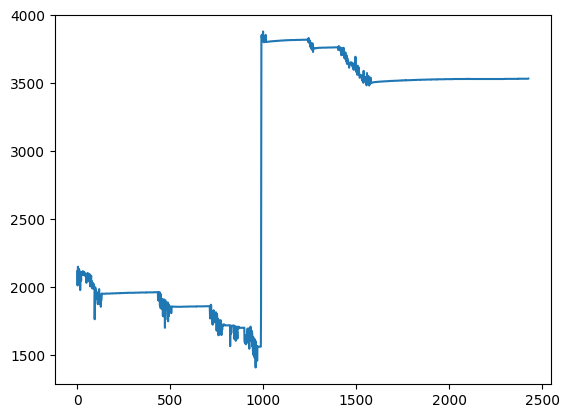

In [61]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['Value fs01'])
#plt.plot(fs02_x_values,values_dates_fs02_ordered['Value fs02'])

In [62]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

In [63]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.1033
b1=4.2652
m2=0.066
b2=4.7161

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
RangeIndex: 2427 entries, 0 to 2426
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Value fs01  2427 non-null   int64
 1   Dates fs01  2427 non-null   int64
 2   raw data    2427 non-null   str  
dtypes: int64(2), str(1)
memory usage: 57.0 KB


In [64]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1_='260815124025'   #Local time, program will turn to UTC.
date2_='260815134025'   #Local time, program will turn to UTC.
date1_formated=datetime.strptime(date1_, "%y%m%d%H%M%S") #It must be an epoch number
date2_formated=datetime.strptime(date2_, "%y%m%d%H%M%S")

date1_formated.replace(tzinfo=timezone.utc)
date2_formated.replace(tzinfo=timezone.utc)

date1=int(date1_formated.timestamp())
date2=int(date2_formated.timestamp())

print(date1,date2)

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

1786815625 1786819225
Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
droping 101.09774048373072 101.56165299840545 -0.4639125146747318
raising 101.2887632838909 101.09774048373072 -0.27288971451454813
raising 101.80725374146857 101.2887632838909 0.24560074306312174
droping 101.56165299840545 101.80725374146857 0.0
droping 101.2887632838909 101.56165299840545 -0.27288971451454813
raising 101.80725374146857 101.2887632838909 0.24560074306312174
droping 101.56165299840545 101.80725374146857 0.0
droping 101.20689636953652 101.56165299840545 -0.3547566288689268
raising 101.34334122679381 101.20689636953652 -0.2183117716116385
droping 101.31605225534236 101.34334122679381 -0.24560074306309332
droping 101.23418534098798 101.31605225534236 -0.32746765741747197
droping 100.96129562647343 101.23418534098798 -0.6003573719320201
raising 101.56165299840545 100.96129562647343 0.0
droping 100.98858459792488 101.56165299840545 -0.5730684004805653
raising 101.234185